# Portfolio overlap between two 13F managers

Take the two largest reported holders of one stock, pull each manager's
full latest portfolio, and measure how much they overlap.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import itertools

import pandas as pd

from py3spread import Client

client = Client()

CUSIP = "037833100"  # apple
PERIOD = "2026-03-31"

holders = client.institutional_holdings.holdings(
    cusip=CUSIP, period=PERIOD, min_value=1_000_000_000,
    sort="value", order="desc", limit=10,
)["data"]

# first two distinct managers
managers = list({h["filing_manager_cik"]: h["filing_manager_name"] for h in holders}.items())[:2]
managers

[('2100119', 'VANGUARD CAPITAL MANAGEMENT LLC'),
 ('93751', 'STATE STREET CORP')]

In [2]:
CAP = 3000  # cap rows per portfolio to keep the pull quick

def load_portfolio(cik):
    filing = client.institutional_holdings.list(filing_manager_cik=cik, limit=1)["data"][0]
    rows = list(itertools.islice(
        client.institutional_holdings.iter_holdings(filing_id=filing["filing_id"]), CAP))
    df = pd.DataFrame(rows)
    df["value_usd"] = pd.to_numeric(df["value_usd"])
    df = df.groupby(["cusip", "name_of_issuer"], as_index=False)["value_usd"].sum()
    df["weight"] = df["value_usd"] / df["value_usd"].sum()
    if len(rows) == CAP:
        print(f"note: capped at {CAP} rows, weights are approximate")
    return filing, df

filing_a, port_a = load_portfolio(managers[0][0])
filing_b, port_b = load_portfolio(managers[1][0])
name_a, name_b = managers[0][1], managers[1][1]
print(f"{name_a}: {len(port_a)} positions, period {filing_a['period_of_report']}")
print(f"{name_b}: {len(port_b)} positions, period {filing_b['period_of_report']}")

note: capped at 3000 rows, weights are approximate


note: capped at 3000 rows, weights are approximate
VANGUARD CAPITAL MANAGEMENT LLC: 3000 positions, period 2026-03-31
STATE STREET CORP: 3000 positions, period 2026-03-31


## How much do they overlap

Overlap score is the sum over common positions of the smaller weight,
so 100% means identical portfolios and 0% means no common holdings.

In [3]:
merged = port_a.merge(port_b, on="cusip", suffixes=("_a", "_b"))
overlap = merged[["weight_a", "weight_b"]].min(axis=1).sum()

print(f"common positions: {len(merged)}")
print(f"portfolio overlap: {overlap:.1%}")

merged["combined"] = merged["weight_a"] + merged["weight_b"]
top = merged.sort_values("combined", ascending=False).head(8)
top[["name_of_issuer_a", "weight_a", "weight_b"]].rename(
    columns={"name_of_issuer_a": "issuer", "weight_a": name_a, "weight_b": name_b}
).style.format({name_a: "{:.2%}", name_b: "{:.2%}"})

common positions: 1969
portfolio overlap: 68.8%


,issuer,VANGUARD CAPITAL MANAGEMENT LLC,STATE STREET CORP
1681,NVIDIA CORPORATION,9.34%,7.48%
1520,MICROSOFT CORP,6.21%,4.90%
115,AMAZON COM INC,4.57%,3.51%
104,ALPHABET INC,3.78%,2.81%
103,ALPHABET INC,3.01%,2.30%
859,META PLATFORMS INC,2.83%,2.18%
305,BERKSHIRE HATHAWAY INC DEL,1.96%,1.53%
1255,JPMORGAN CHASE & CO,1.69%,1.58%


## Largest common positions

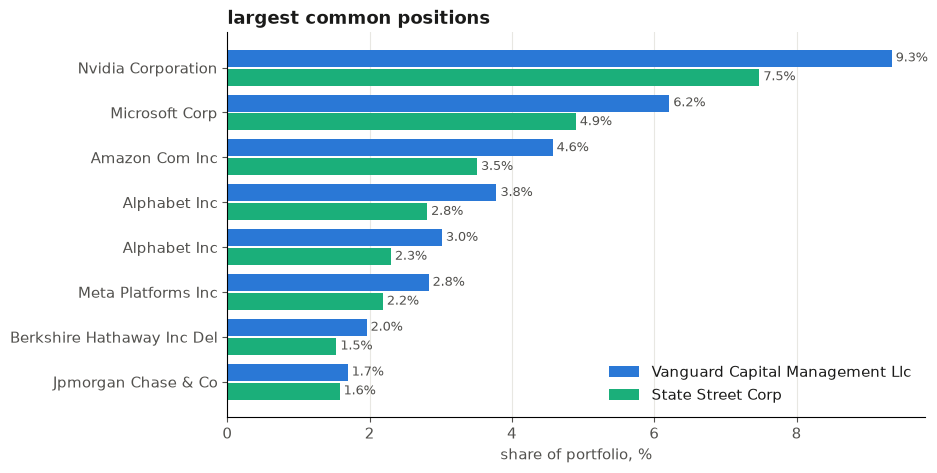

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
AQUA = "#1baf7a"
INK = "#52514e"


import numpy as np

labels = top["name_of_issuer_a"].str.title()
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y + 0.21, top["weight_a"] * 100, height=0.38, color=BLUE, label=name_a.title())
ax.barh(y - 0.21, top["weight_b"] * 100, height=0.38, color=AQUA, label=name_b.title())
for yy, w in zip(y + 0.21, top["weight_a"] * 100):
    ax.text(w, yy, f" {w:.1f}%", va="center", fontsize=9, color=INK)
for yy, w in zip(y - 0.21, top["weight_b"] * 100):
    ax.text(w, yy, f" {w:.1f}%", va="center", fontsize=9, color=INK)
ax.set_yticks(y, labels)
ax.set_xlabel("share of portfolio, %")
ax.set_title("largest common positions", loc="left", fontweight="bold")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right")
plt.show()

Swap in any two manager CIKs, or loop the pairwise overlap across the whole
holder list to build a similarity matrix.